<a id='Top'></a>

# Prepare Clinical Data for Survival Analysis <a class='tocSkip'></a>


This script processes clinical data for different cancer types, ensuring that only patients present in the manifest are included. This guarantees the selection of multimodal patients, which is essential for integrated analysis. The data undergoes several preprocessing steps, including handling missing values, imputing numeric fields, calculating survival time based on event status, and removing unnecessary or repeated columns. 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
def process_clinical_data(cancer_type):
    """
    Process and clean clinical data for a given cancer type:
    - Load and filter datasets
    - Clean and preprocess missing values
    - Compute survival time
    - Remove unnecessary columns
    """
    
    # Define file paths
    base_path = "../data_download"
    manifest_path = f"{base_path}/Manifest/{cancer_type}/filtered_manifest/filtered_gdc_manifest.clinical.txt"
    sample_sheet_path = f"{base_path}/Sample_sheets/{cancer_type}/gdc_sample_sheet.clinical.tsv"
    
    # Load datasets
    manifest_df = pd.read_csv(manifest_path, sep="\t")
    sample_sheet_df = pd.read_csv(sample_sheet_path, sep="\t")
    
    # Filter rows where 'case_id' in sample sheet matches the manifest
    filtered_df = sample_sheet_df[sample_sheet_df['case_id'].isin(manifest_df['case_id'])].copy()
    number_patients = filtered_df.shape[0]
    columns_before = filtered_df.shape[1]
    
    # Replace problematic values with NaN
    filtered_df = filtered_df.replace({'--': pd.NA, 'Not reported': pd.NA, "'--": pd.NA})
    
    # Remove columns with no variability or entirely NaN values
    filtered_df = filtered_df.loc[:, filtered_df.nunique(dropna=True) > 1].dropna(axis=1, how='all')
    
    # Impute missing numeric values with the mean
    for col in filtered_df.select_dtypes(include=['float64', 'int64']).columns:
        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')  # Ensure numeric conversion
        if filtered_df[col].isnull().any():
            mean_value = filtered_df[col].mean()
            filtered_df[col] = filtered_df[col].fillna(mean_value)
            print(f"Imputed missing values in column '{col}' with the mean value: {mean_value}")
    
    # Function to compute survival time
    def get_duration(event, days_to_death, days_to_last_follow_up):
        if event == 1:
            return days_to_death
        elif event == 0:
            return days_to_last_follow_up
        return None
    
    # Process clinical data
    filtered_df = filtered_df.rename(columns={'vital_status': 'event'})
    filtered_df['event'] = filtered_df['event'].map({'Dead': 1, 'Alive': 0})
    
    # Convert time-related columns to numeric
    filtered_df['days_to_death'] = pd.to_numeric(filtered_df.get('days_to_death'), errors='coerce')
    filtered_df['days_to_last_follow_up'] = pd.to_numeric(filtered_df.get('days_to_last_follow_up'), errors='coerce')
    
    # Compute 'time' column
    filtered_df['time'] = filtered_df.apply(lambda x: get_duration(x['event'], x['days_to_death'], x['days_to_last_follow_up']), axis=1)
    filtered_df['time'] = pd.to_numeric(filtered_df['time'], errors='coerce')
    
    # Drop unnecessary columns
    filtered_df = filtered_df.drop(columns=['days_to_death', 'days_to_last_follow_up', 'ethnicity', 'synchronous_malignancy',
                                             'days_to_birth', 'year_of_birth', 'year_of_death', 'icd_10_code',
                                             'treatment_type', 'site_of_resection_or_biopsy'])   
    filtered_df['race'] = filtered_df['race'].fillna('other')
    
    # Remove columns with more than 50% missing values
    filtered_df = filtered_df.dropna(axis=1, thresh=len(filtered_df) * 0.5)
    
    # Remove 'case_submitter_id' if present
    if 'case_submitter_id' in filtered_df.columns:
        filtered_df.drop(columns=['case_submitter_id'], inplace=True)
    
    columns_after = filtered_df.shape[1]
    shape = filtered_df.shape
    
    # Print summary
    print(f"\nNumber of patients in {cancer_type}: {number_patients}")
    print(f"\nNumber of columns before in {cancer_type}: {columns_before}")
    print(f"Number of columns after in {cancer_type}: {columns_after}")
    print(f"Final shape of {cancer_type}: {shape}\n")
    display(filtered_df)

    # Output path based on cancer type
    output_path = f"../samvae-main/data_preprocessing/raw_data/clinical_data/{cancer_type.lower()}/{cancer_type.lower()}_clinical.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    filtered_df.to_csv(output_path, index=False)
    
# Process LGG and BRCA datasets
for cancer in ["LGG", "BRCA"]:
    process_clinical_data(cancer)



Number of patients in LGG: 520

Number of columns before in LGG: 197
Number of columns after in LGG: 14
Final shape of LGG: (520, 14)



,case_id,age_at_index,gender,race,event,age_at_diagnosis,morphology,primary_diagnosis,prior_malignancy,prior_treatment,tissue_or_organ_of_origin,year_of_diagnosis,treatment_or_therapy,time
0,001ad307-4ad3-4f1d-b2fc-efc032871c7e,47,male,white,0,17392,9382/3,Mixed glioma,no,No,Cerebrum,2013,not reported,82.0
1,001ad307-4ad3-4f1d-b2fc-efc032871c7e,47,male,white,0,17392,9382/3,Mixed glioma,no,No,Cerebrum,2013,not reported,82.0
2,0061e9ef-df6a-414e-af64-c88f8192e2d3,31,male,white,1,11332,9451/3,"Oligodendroglioma, anaplastic",no,No,"Brain, NOS",1994,yes,4084.0
3,0061e9ef-df6a-414e-af64-c88f8192e2d3,31,male,white,1,11332,9451/3,"Oligodendroglioma, anaplastic",no,No,"Brain, NOS",1994,yes,4084.0
4,0073a136-d5f4-4fd6-88f9-711768f2abc6,44,female,white,0,16334,9401/3,"Astrocytoma, anaplastic",no,No,Cerebrum,2013,yes,609.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,81076cfb-f9d7-4add-b696-6eab0bad7945,21,male,white,0,7760,9400/3,"Astrocytoma, NOS",no,No,Cerebrum,2008,not reported,3.0
516,81622da8-9f36-4ea3-b223-d831d8c10f87,33,male,white,1,12266,9401/3,"Astrocytoma, anaplastic",no,No,Cerebrum,2006,yes,1339.0
517,81622da8-9f36-4ea3-b223-d831d8c10f87,33,male,white,1,12266,9401/3,"Astrocytoma, anaplastic",no,No,Cerebrum,2006,yes,1339.0
518,81fb338f-1023-49aa-ac0f-ba763a6cd68c,26,female,white,0,9539,9450/3,"Oligodendroglioma, NOS",no,No,Cerebrum,2011,no,76.0



Number of patients in BRCA: 1057

Number of columns before in BRCA: 197
Number of columns after in BRCA: 19
Final shape of BRCA: (1057, 19)



,case_id,age_at_index,gender,race,event,age_at_diagnosis,ajcc_pathologic_m,ajcc_pathologic_n,ajcc_pathologic_stage,ajcc_pathologic_t,ajcc_staging_system_edition,morphology,primary_diagnosis,prior_malignancy,prior_treatment,tissue_or_organ_of_origin,year_of_diagnosis,treatment_or_therapy,time
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,60,female,white,0.0,22279,M0,N0 (mol+),Stage IA,T1c,7th,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2010,no,337.0
1,001cef41-ff86-4d3f-a140-a647ac4b10a1,60,female,white,0.0,22279,M0,N0 (mol+),Stage IA,T1c,7th,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2010,yes,337.0
2,0045349c-69d9-4306-a403-c9c1fa836644,70,female,white,0.0,25833,M0,N0,Stage I,T1c,6th,8200/3,Adenoid cystic carcinoma,no,No,"Breast, NOS",2008,not reported,259.0
3,0045349c-69d9-4306-a403-c9c1fa836644,70,female,white,0.0,25833,M0,N0,Stage I,T1c,6th,8200/3,Adenoid cystic carcinoma,no,No,"Breast, NOS",2008,not reported,259.0
4,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,50,female,white,0.0,18345,M0,N1mi,Stage IIB,T2,6th,8401/3,Apocrine adenocarcinoma,no,No,"Breast, NOS",2005,no,3102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1052,786e8dbe-442e-4551-87b3-b4c333b04dd4,82,female,white,0.0,30025,M0,N0 (i-),Stage I,T1c,6th,8575/3,"Metaplastic carcinoma, NOS",no,No,"Breast, NOS",2008,no,701.0
1053,7875018b-91dc-4ab1-83b0-ee3883e2816e,62,female,white,0.0,23006,M0,N1a,Stage IIA,T1c,<NA>,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2007,yes,1270.0
1054,7875018b-91dc-4ab1-83b0-ee3883e2816e,62,female,white,0.0,23006,M0,N1a,Stage IIA,T1c,<NA>,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2007,yes,1270.0
1055,78e1da41-127c-4e9c-aaaa-77a0d94c31d0,65,female,not reported,0.0,24017,M0,N0,Stage IIA,T2,6th,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2008,yes,881.0


# Special Case: BRCA

For BRCA, we limit the dataset to 500 patients due to computational and storage constraints. This also helps maintain a comparable number of patients between BRCA and LGG, ensuring a balanced analysis while optimizing resource usage.

In [3]:
# Path to the dataset  
dataset_path = "../samvae-main/data_preprocessing/raw_data/clinical_data/brca/brca_clinical.csv"

# Load the dataset  
df = pd.read_csv(dataset_path, sep=",")

# Remove duplicate case_id entries and keep only the first 500 rows  
df_unique = df.drop_duplicates(subset="case_id").head(500)

# Display the resulting DataFrame  
display(df_unique)
df_unique.to_csv(dataset_path, index=False)  # Saves only the first 500 unique cases


,case_id,age_at_index,gender,race,event,age_at_diagnosis,ajcc_pathologic_m,ajcc_pathologic_n,ajcc_pathologic_stage,ajcc_pathologic_t,ajcc_staging_system_edition,morphology,primary_diagnosis,prior_malignancy,prior_treatment,tissue_or_organ_of_origin,year_of_diagnosis,treatment_or_therapy,time
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,60.0,female,white,0.0,22279.0,M0,N0 (mol+),Stage IA,T1c,7th,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2010.0,no,337.0
2,0045349c-69d9-4306-a403-c9c1fa836644,70.0,female,white,0.0,25833.0,M0,N0,Stage I,T1c,6th,8200/3,Adenoid cystic carcinoma,no,No,"Breast, NOS",2008.0,not reported,259.0
4,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,50.0,female,white,0.0,18345.0,M0,N1mi,Stage IIB,T2,6th,8401/3,Apocrine adenocarcinoma,no,No,"Breast, NOS",2005.0,no,3102.0
6,00a2d166-78c9-4687-a195-3d6315c27574,56.0,female,white,0.0,20713.0,M0,N0,Stage IIA,T2,NaN,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2010.0,no,5.0
8,00b11ca8-8540-4a3d-b602-ec754b00230b,61.0,female,white,0.0,22497.0,MX,N0 (i-),Stage IA,T1c,7th,8520/3,"Lobular carcinoma, NOS",yes,No,"Breast, NOS",2012.0,yes,759.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,71fc8941-4cfb-47ea-a533-873d38f8c95c,37.0,female,white,0.0,13671.0,M0,N0,Stage I,T1c,6th,8500/3,"Infiltrating duct carcinoma, NOS",no,No,"Breast, NOS",2009.0,yes,1855.0
991,7241b3d4-31ee-4fd2-a4a5-35a9d5f37d6a,46.0,female,white,0.0,17039.0,M0,N0,Stage IIA,T2,6th,8520/3,"Lobular carcinoma, NOS",no,No,"Breast, NOS",2008.0,yes,984.0
993,726c6892-0dce-4869-a7a7-cc44c26fe843,49.0,female,white,0.0,18038.0,M0,N1,Stage IIB,T2,7th,8524/3,Infiltrating lobular mixed with other types of...,no,No,"Breast, NOS",2013.0,yes,592.0
995,72cd1b17-d349-4551-83f7-3062ce9db865,62.0,female,white,0.0,22961.0,M0,N0 (i+),Stage I,T1c,6th,8522/3,Infiltrating duct and lobular carcinoma,no,No,"Breast, NOS",2009.0,yes,1505.0


# Exploratory Data Analysis of LGG


Processing clinical data for BRCA...


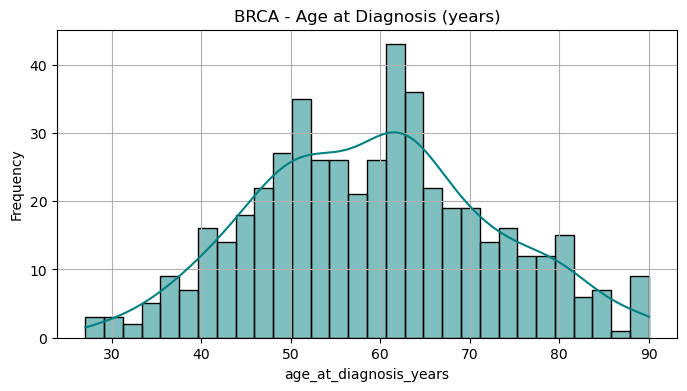

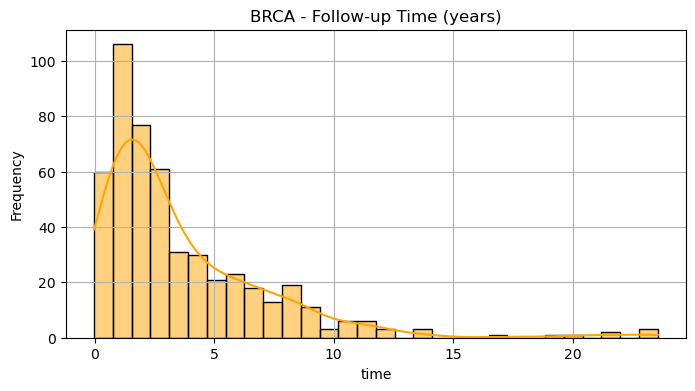

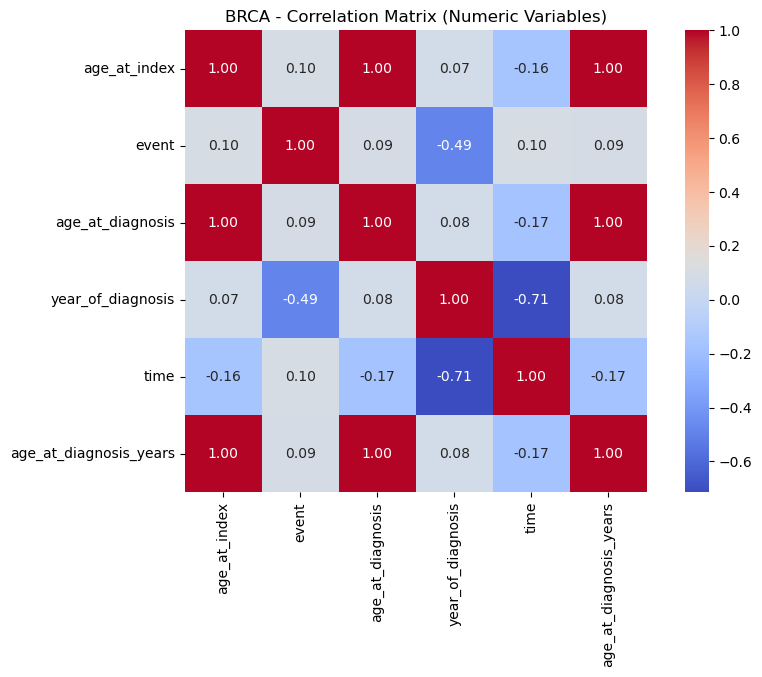


Processing clinical data for LGG...


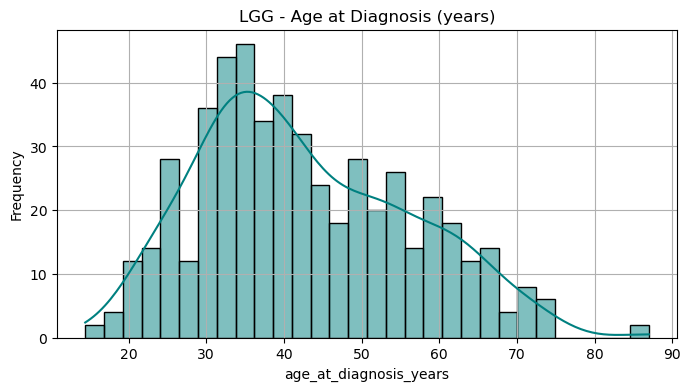

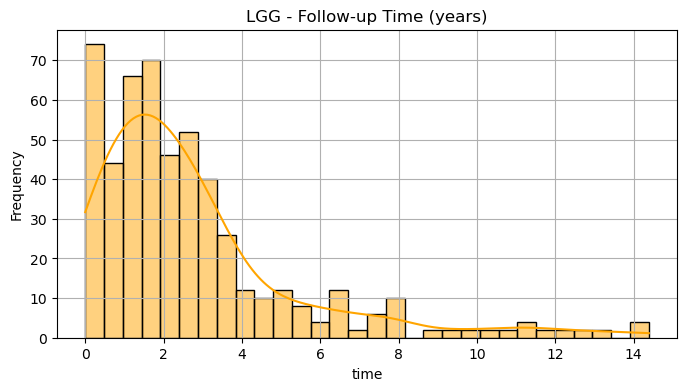

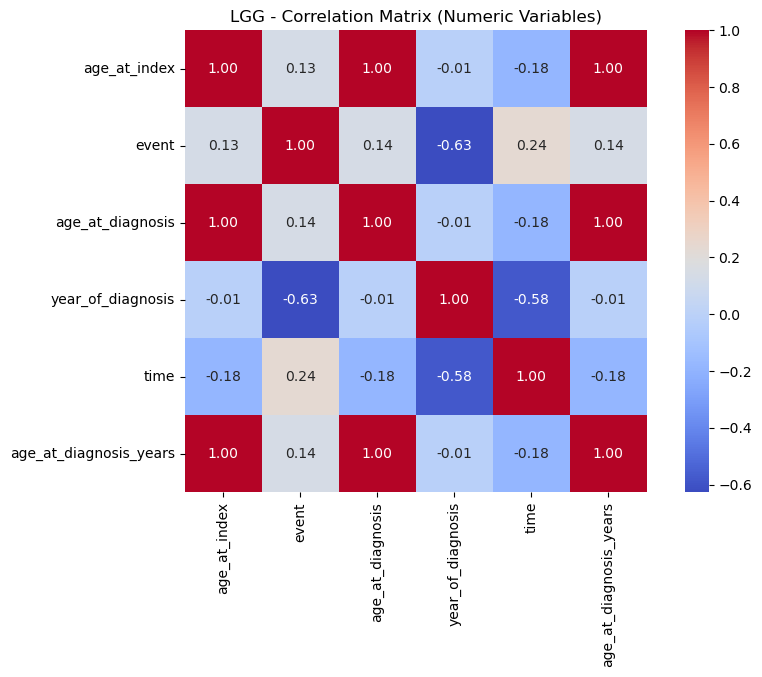

In [4]:
# Dictionary with cancer types and their clinical data file paths
clinical_data_paths = {
    "BRCA": "../samvae-main/data_preprocessing/raw_data/clinical_data/brca/brca_clinical.csv",
    "LGG": "../samvae-main/data_preprocessing/raw_data/clinical_data/lgg/lgg_clinical.csv"
}

# Function to plot numerical distribution
def plot_numerical_distribution(df, col_name, title=None, color="steelblue"):
    if col_name in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col_name].dropna(), bins=30, kde=True, color=color)
        plt.title(title or f'Distribution of {col_name}')
        plt.xlabel(col_name)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

# Process each cancer type
for cancer_type, file_path in clinical_data_paths.items():
    if not os.path.exists(file_path):
        print(f"File not found for {cancer_type}: {file_path}")
        continue

    print(f"\nProcessing clinical data for {cancer_type}...")

    # Load clinical data
    df = pd.read_csv(file_path)

    # Convert age and time to years if present
    if 'age_at_diagnosis' in df.columns:
        df['age_at_diagnosis_years'] = df['age_at_diagnosis'] / 365.25
    if 'time' in df.columns:
        df['time'] = df['time'] / 365.25

    # Plot distributions
    plot_numerical_distribution(df, 'age_at_diagnosis_years', f'{cancer_type} - Age at Diagnosis (years)', color='teal') 
    plot_numerical_distribution(df, 'time', f'{cancer_type} - Follow-up Time (years)', color='orange')

    # Correlation matrix
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(10, 6))
        corr = df[numeric_cols].corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
        plt.title(f'{cancer_type} - Correlation Matrix (Numeric Variables)')
        plt.show()